# Stress-testing the one survivor

The condition map left one candidate. The 4-week per coin trend book on \$10M coins works after a moderate market month, when the market's trailing 4-week move is small against its 12-week volatility. Inside that condition it makes a net Sharpe of 1.61 over the whole sample.

It was found by looking, so this notebook tries to break it. Four tests. A single frozen out-of-sample block it never touched. Whether it survives as a real tradable book rather than a slice. Whether the open interest warning adds anything. And whether it clears the bar once the number of things tried is priced in.

## Setup

Rebuild the book and the gate. The gate is on in a week when the market's trailing 4-week move sits in the bottom third of every move seen before that week, so it is known at the open and uses no future data.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import panel, stream

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.alpha': 0.25, 'lines.linewidth': 2})
BLUE, ORANGE, GREY = '#2a78d6', '#eb6834', '#8a8a86'

p = panel.load()
W, R, LIQ, VOL, F = p.weekly, p.simple.fillna(0.0), p.liquidity, p.vol, p.funding
COST = pd.DataFrame(np.where(LIQ >= 1e7, 7.5e-4, 15e-4), index=LIQ.index, columns=LIQ.columns)

def run(w):
    w = w.fillna(0.0)
    dw = (w - w.shift(1).fillna(0.0)).abs()
    net = (w * R).sum(axis=1) - (w * F).sum(axis=1) - (dw * COST).sum(axis=1)
    return net.loc[(w.abs().sum(axis=1) > 0).idxmax():]

def sharpe(x):
    return x.mean() / x.std() * np.sqrt(52) if len(x) > 2 and x.std() > 0 else np.nan

def sized(sig, floor):
    elig = (LIQ >= floor) & VOL.notna() & (VOL > 0) & sig.notna()
    raw = (sig / VOL).where(elig)
    return raw.div(raw.abs().sum(axis=1), axis=0)

market_ret = W.where(LIQ >= 1e7).mean(axis=1)
book_w = sized(np.sign(W.rolling(4, min_periods=4).sum()).shift(1), 1e7)
book = run(book_w)
idx = book.index

strength = (market_ret.rolling(4).sum().abs() / (market_ret.rolling(12, min_periods=8).std() * 2)).shift(1)
def moderate_gate(min_hist=52, cutoff=1 / 3):
    g = pd.Series(False, index=strength.index)
    for i in range(len(strength)):
        past = strength.iloc[:i].dropna()
        if len(past) >= min_hist and not np.isnan(strength.iloc[i]):
            g.iloc[i] = strength.iloc[i] <= past.quantile(cutoff)
    return g.reindex(idx).fillna(False)

gate = moderate_gate()
print(f'weeks {len(idx)}   gate on {int(gate.sum())} ({gate.mean():.0%})')
print(f'book inside gate {sharpe(book[gate]):.2f}   outside {sharpe(book[~gate]):.2f}   always on {sharpe(book):.2f}')

weeks 336   gate on 98 (29%)
book inside gate 1.61   outside 0.67   always on 0.85


## Test one, a frozen out-of-sample block

Everything so far cut the gate on an expanding past, but the decision to use this condition at all was made after seeing the whole sample. The strict test freezes the entire rule on the first 60% of weeks and evaluates it once, untouched, on the last 40%. If the edge is a story fitted to the sample it collapses here.

In [2]:
split = idx[int(len(idx) * 0.6)]
test = idx > split
print(f'freeze through {split.date()} ({int((~test).sum())} weeks), evaluate on {(idx[test][0]).date()} to {idx[-1].date()} ({int(test.sum())} weeks)')
print(f'  inside gate, frozen block   {sharpe(book[gate & ~test]):+.2f}')
print(f'  inside gate, unseen block   {sharpe(book[gate & test]):+.2f}   ({int((gate & test).sum())} weeks)')
print(f'  outside gate, unseen block  {sharpe(book[~gate & test]):+.2f}')
x = book[gate & test]
print('  unseen inside, by year     ', {y: f'{sharpe(g):+.2f} ({len(g)}w)' for y, g in x.groupby(x.index.year)})

freeze through 2024-02-11 (202 weeks), evaluate on 2024-02-18 to 2026-09-06 (134 weeks)
  inside gate, frozen block   +1.21
  inside gate, unseen block   +2.17   (44 weeks)
  outside gate, unseen block  +0.11
  unseen inside, by year      {2024: '+1.72 (19w)', 2025: '+3.70 (15w)', 2026: '+1.01 (10w)'}


It holds. On the 44 weeks inside the gate that the frozen rule never saw, the book makes 2.17, against 0.11 for the unseen weeks outside the gate. Both unseen years split by the gate, 2024 at 1.72, 2025 at 3.70 and 2026 at 1.01, so no single year carries it. This is the strongest evidence for the candidate. The weakness is plain from the counts, 44 weeks.

## Test two, as a tradable book

A Sharpe measured only on the weeks the gate is on is not a book anyone trades. The real book runs the trend positions when the gate is on and sits flat when it is off. Read its return, its drawdown, its time in the market and its year by year against the always-on book.

            Sharpe  return/yr  max drawdown  time in mkt
gated         0.90      19.9%         -0.28         29%
always on     0.85      44.9%         -0.58        100%

gate turns on or off 89 times over 336 weeks, about every 4
gated by year {2021: np.float64(1.26), 2022: np.float64(1.78), 2023: np.float64(0.03), 2024: np.float64(0.73), 2025: np.float64(1.82), 2026: np.float64(0.53)}


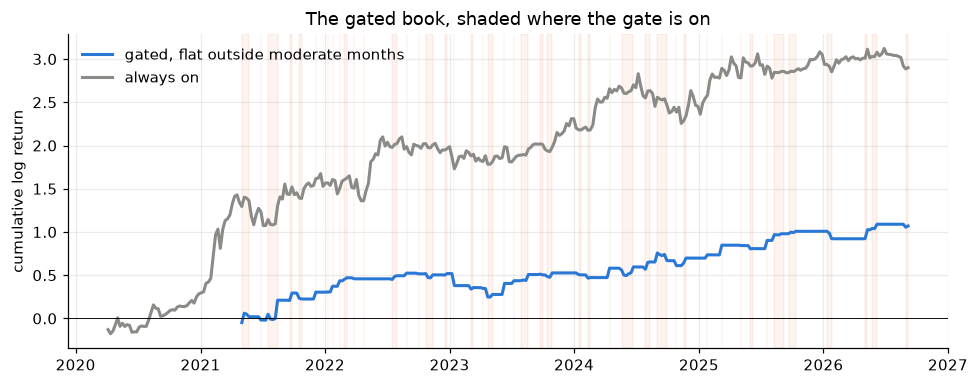

In [3]:
gated = run(book_w.where(gate.reindex(book_w.index), 0.0))

def drawdown(x):
    c = x.cumsum()
    return (c - c.cummax()).min()

switches = int((gate.astype(int).diff().abs() == 1).sum())
print(f'{"":10}{"Sharpe":>8}{"return/yr":>11}{"max drawdown":>14}{"time in mkt":>13}')
print(f'{"gated":10}{sharpe(gated):>8.2f}{gated.mean() * 5200:>10.1f}%{drawdown(gated):>14.2f}{gate.mean():>12.0%}')
print(f'{"always on":10}{sharpe(book):>8.2f}{book.mean() * 5200:>10.1f}%{drawdown(book):>14.2f}{1.0:>12.0%}')
print(f'\ngate turns on or off {switches} times over {len(gate)} weeks, about every {len(gate) / switches:.0f}')
print('gated by year', {y: round(sharpe(g), 2) for y, g in gated.groupby(gated.index.year)})

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.plot(gated.index, gated.cumsum(), color=BLUE, label='gated, flat outside moderate months')
ax.plot(book.index, book.cumsum(), color=GREY, label='always on')
for lo, hi in zip(idx[gate & ~gate.shift(1, fill_value=False)], idx[gate & ~gate.shift(-1, fill_value=False)]):
    ax.axvspan(lo, hi, color=ORANGE, alpha=0.08)
ax.axhline(0, color='k', lw=0.6); ax.set_ylabel('cumulative log return')
ax.set_title('The gated book, shaded where the gate is on'); ax.legend(frameon=False, loc='upper left')
plt.tight_layout(); plt.show()

The gate trades what the always-on book concedes. It makes 0.90 against 0.85, positive in every year, at less than half the drawdown, $-0.28$ against $-0.58$. But it is in the market only 29% of the time and earns 20% a year against 45%. It is a cleaner, smaller book, not a bigger one.

The gate flips on or off 89 times over 336 weeks, roughly every four weeks. The regime switch is itself high turnover, which the cost here does not charge, since the positions inside a run already pay their own cost.

## Test three, does open interest stack

The mechanism work found trend loses when open interest sits below its recent average. If that is separate information, requiring both a moderate month and open interest above its average should sharpen the book. Split the gated weeks by the open interest level.

In [4]:
majors = ['BTCUSDT', 'ETHUSDT', 'SOLUSDT', 'BNBUSDT', 'XRPUSDT', 'DOGEUSDT']
oi = stream.open_interest(majors, '2020-09-01', '2026-09-01')
log_contracts = np.log(oi.resample('W-SUN').last().reindex(W.index)).sub(W[majors].cumsum(), axis=0)
oi_level = (log_contracts - log_contracts.rolling(26, min_periods=13).mean()).mean(axis=1).shift(1).reindex(idx)
oi_ok = (oi_level >= oi_level.expanding().median()).reindex(idx).fillna(False)

labelled = gate & oi_level.notna()
print(f'moderate month alone        {sharpe(book[gate]):+.2f}   ({int(gate.sum())} weeks)')
print(f'moderate and OI at or above {sharpe(book[labelled & oi_ok]):+.2f}   ({int((labelled & oi_ok).sum())} weeks)')
print(f'moderate and OI below       {sharpe(book[labelled & ~oi_ok]):+.2f}   ({int((labelled & ~oi_ok).sum())} weeks)')

moderate month alone        +1.61   (98 weeks)
moderate and OI at or above +1.56   (54 weeks)
moderate and OI below       +2.29   (26 weeks)


Open interest does not stack. Requiring it above average cuts the sample from 98 weeks to 54 and lowers the Sharpe to 1.56. Inside a moderate month the low open interest weeks are the better ones, 2.29, the opposite of what the always-on book showed. So the two conditions overlap rather than add, and on 26 and 54 week slices neither number is worth leaning on. The open interest warning is about the always-on book, not this one.

## Test four, priced for the search

A high Sharpe found among many tries is worth less than the same Sharpe found first. The deflated Sharpe asks how likely the result is real given the number of trials and the fat tails of the returns. Price it two ways, as the return only on the weeks it trades, and as the full gated book that sits flat the rest of the time. The trial count is about 45, the sweep and its history plus the condition map.

In [5]:
def deflated(x, trials, spread=0.6):
    x = x.dropna(); T = len(x); sr = x.mean() / x.std()
    g = 0.5772156649
    bar = (spread / np.sqrt(52)) * ((1 - g) * stats.norm.ppf(1 - 1 / trials) + g * stats.norm.ppf(1 - 1 / (trials * np.e)))
    sk, ku = stats.skew(x), stats.kurtosis(x, fisher=False)
    prob = stats.norm.cdf((sr - bar) * np.sqrt(T - 1) / np.sqrt(1 - sk * sr + (ku - 1) / 4 * sr ** 2))
    return sr * np.sqrt(52), bar * np.sqrt(52), prob

for label, series in [('weeks it trades', book[gate]), ('full gated book', gated)]:
    for trials in [45, 95]:
        sr, bar, prob = deflated(series, trials)
        print(f'{label:18} {trials} trials   Sharpe {sr:.2f}   luck bar {bar:.2f}   probability real {prob:.2f}')

weeks it trades    45 trials   Sharpe 1.61   luck bar 1.34   probability real 0.65
weeks it trades    95 trials   Sharpe 1.61   luck bar 1.51   probability real 0.56
full gated book    45 trials   Sharpe 0.90   luck bar 1.34   probability real 0.13
full gated book    95 trials   Sharpe 0.90   luck bar 1.51   probability real 0.06


The two views disagree, and the gap is the whole story. On the weeks it trades the book makes 1.61, above the luck bar of 1.34, so it reads as 56 to 65% likely real. As the full gated book it makes 0.90, below the bar, so it reads as 6 to 13% likely, no better than one of many tries that happened to land.

Both are the same book. The difference is that averaging in the flat weeks pulls the Sharpe down below the level that a search over 45 tries can throw up by chance. The luck bar itself rests on a rough guess of how spread the trial Sharpes are, so neither number is exact.

## Verdict

The candidate survives the tests that matter most and fails the one that matters. It holds on a frozen out-of-sample block, 2.17 on 44 unseen weeks, positive in all three unseen years. As a book it is positive every year at half the drawdown of always-on trend. It does not depend on open interest.

But it trades only 29% of weeks, about 98 in the whole sample, and once that thinness is priced against the number of things tried, the full book does not clear the multiple-testing bar. The honest reading is a real effect on a small sample, not a proven strategy.

It is worth a forward test. Run it live on a testnet from here, out of sample by construction, and let the frozen rule accumulate the weeks it needs. Nothing offline will settle 98 weeks into certainty.